In [1]:
import os, re, json, shutil
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['font.sans-serif'] = ['NanumGothic'] + plt.rcParams['font.sans-serif']
matplotlib.rcParams['axes.unicode_minus'] = False

DATA = Path('..') / 'data'
csv_path = DATA / '위원회회의록.csv'
pdf_dir = DATA / 'assembly_pdf'
txt_dir = DATA / 'assembly_txt'
txt_dir.mkdir(exist_ok=True)

if not csv_path.exists():
    raise FileNotFoundError(
        f"누락: {csv_path}\n배포 받은 data/ 폴더를 프로젝트 루트에 압축 해제했는지 확인하세요."
    )

df = pd.read_csv(csv_path, encoding='euc-kr')
confer_nums = sorted(df['회의번호'].unique())

n_pdf = len(list(pdf_dir.glob('*.pdf'))) if pdf_dir.exists() else 0
n_txt = len(list(txt_dir.glob('*.txt')))

print(f"✓ CSV: {len(df)}행, {df['회의번호'].nunique()}개 회의")
print(f"  PDF: {n_pdf}개  (data/assembly_pdf/)")
print(f"  TXT: {n_txt}개  (data/assembly_txt/)")
print()

✓ CSV: 421행, 19개 회의
  PDF: 19개  (data/assembly_pdf/)
  TXT: 19개  (data/assembly_txt/)



In [13]:
import pdfplumber
DEMO_IDS = [56254, 56297, 56351, 56419, 56481]


In [3]:
import glob

In [4]:
glob.glob('../data/assembly_pdf/*.pdf')

['../data/assembly_pdf/56350.pdf',
 '../data/assembly_pdf/56297.pdf',
 '../data/assembly_pdf/56488.pdf',
 '../data/assembly_pdf/56487.pdf',
 '../data/assembly_pdf/56351.pdf',
 '../data/assembly_pdf/56481.pdf',
 '../data/assembly_pdf/56431.pdf',
 '../data/assembly_pdf/56519.pdf',
 '../data/assembly_pdf/56330.pdf',
 '../data/assembly_pdf/56352.pdf',
 '../data/assembly_pdf/56296.pdf',
 '../data/assembly_pdf/56254.pdf',
 '../data/assembly_pdf/56366.pdf',
 '../data/assembly_pdf/56367.pdf',
 '../data/assembly_pdf/56236.pdf',
 '../data/assembly_pdf/56419.pdf',
 '../data/assembly_pdf/56255.pdf',
 '../data/assembly_pdf/56204.pdf',
 '../data/assembly_pdf/56430.pdf']

In [22]:
extract_targets = [
    cn for cn in DEMO_IDS
    if (pdf_dir / f"{cn}.pdf").exists()
]

extract_targets

[56254, 56297, 56351, 56419, 56481]

In [21]:
for cn in extract_targets:
    pdf_path = pdf_dir / f'{cn}.pdf'
    txt_path = txt_dir / f'{cn}.txt'

    if not pdf_path.exists():
        print(f" {cn}.pdf 없음 — 스킵")
        continue

    with pdfplumber.open(pdf_path) as pdf:
        pages = [p.extract_text() or '' for p in pdf.pages]

    row = df[df['회의번호'] == cn].iloc[0]
    header = (
        f"# {row['회의명']}\n"
        f"# 날짜: {row['회의날짜']}\n"
        f"# 회의번호: {cn}\n\n"
    )

    txt_path.write_text(
        header + '\n\n'.join(pages),
        encoding='utf-8'
    )

    print(f" {cn}.txt 추출 완료")

 56254.txt 추출 완료
 56297.txt 추출 완료
 56351.txt 추출 완료
 56419.txt 추출 완료
 56481.txt 추출 완료


In [ ]:
# GraphRAG : project dir -> 
# graphrag init --root {DIR} -> .env , settings.yaml, prompts/~~~~.txt
#     -> settings.yaml : chunk, model, embed model, gleaning
#     -> prompts : entities, relations, rules, 
#     -> .env : load_dotenv() OPENAI_API_KEY : GRAPHRAG_API_KEY
# graphrag index 
#     -> chunking -> extract graph per chunk -> complete graph -> community (leiden)  -> community summary -> parquet
#     1. abc --- is teacher of ---> def
#     2. abc --- teaches ---> def
#     ...
#     5. def --- is student of ---> abc
#     ...
#     10. abc --- studied with ---> def

In [23]:
PROJECT_ROOT = Path('..').resolve() / 'assembly_ragtest_0616'
PROJECT_ROOT.mkdir(exist_ok=True)


In [24]:
!graphrag init --root {PROJECT_ROOT} --model gpt-4o-mini --embedding text-embedding-3-small --force

In [25]:
def preprocess_assembly_text(raw_text):

    lines = raw_text.split('\n')

    cleaned = []

    for line in lines:
        line = line.strip()
        if not line:
            cleaned.append('')
            continue

        if re.match(r'^제\d+회.+\d+$', line):
            continue

        if re.match(r'^\d{1,3}$', line):
            continue

        if re.match(r'^[·...]+$', line):
            continue

        line = re.sub(
            r'^◯(\S+)\s+(\S+)',
            r'[\1 \2]',
            line
        )

        cleaned.append(line)

    text = '\n'.join(cleaned)

    text = re.sub(r'\n{3,}', '\n\n', text)


    return text

In [28]:
input_dir = PROJECT_ROOT / 'input'
DEMO_IDS = [56254, 56297, 56351, 56419, 56481]
for cn in DEMO_IDS:
    raw = (txt_dir / f'{cn}.txt').read_text(encoding='utf-8')
    cleaned = preprocess_assembly_text(raw)

    row = df[df['회의번호'] == cn].iloc[0]
    date_str = row['회의날짜'].replace('-', '')
    fname = f'{date_str}_{cn}.txt'

    (input_dir / fname).write_text(cleaned, encoding='utf-8')


In [34]:
total = sum(len(f.read_text(encoding='utf-8')) for f in input_dir.glob('*.txt'))
total

409389

In [ ]:
# chunking size => 1200  -> 600 ~ 800
# settings.yaml 
# chunking size -> 600
# entity type : [
#     'person', 'organization', 'law', 'committee', 'policy', 'event'
# ]
# graphml : true
# community_reports - max_length : 3000

In [35]:
import yaml

setting_path = PROJECT_ROOT / 'settings.yaml'
with open(setting_path, encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

In [41]:
cfg['chunking']['size'] = 600

cfg['extract_graph']['entity_types'] = [
            'person', 'organization', 'law', 'committee', 'policy', 'event'
        ]
cfg.setdefault('snapshots', {})['graphml'] = True
cfg['community_reports']['max_length'] = 3000

In [42]:
with open(setting_path, 'w', encoding='utf-8') as f:
    yaml.dump(cfg, f, default_flow_style=False, allow_unicode=True, sort_keys=False)

In [43]:
env_path = PROJECT_ROOT / '.env'
api_key = os.environ.get('OPENAI_API_KEY', '')

In [45]:
if not api_key:
    repo_env = PROJECT_ROOT.parent / '.env'
    if repo_env.exists():
        for line in repo_env.read_text().splitlines():
            if line.startswith('OPENAI_API_KEY='):
                api_key = line.split('=',1)[1].strip()
                break

In [48]:
if api_key:
    env_path.write_text(f'GRAPHRAG_API_KEY={api_key}\n')

In [49]:
!graphrag index --root {PROJECT_ROOT}

/home/oncreative/anaconda3/envs/sotaaz_soma/lib/python3.11/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
Starting pipeline with workflows: load_input_documents, create_base_text_units, create_final_documents, extract_graph, finalize_graph, extract_covariates, create_communities, create_final_text_units, create_community_reports, generate_text_embeddings
Starting workflow: load_input_documents

Workflow complete: load_input_documents
Starting workflow: create_base_text_units
  5 / 5 ..........................................

In [50]:
OUTPUT = PROJECT_ROOT / 'output'
for f in sorted(OUTPUT.glob('*.parquet')):
    print(f.name)

communities.parquet
community_reports.parquet
documents.parquet
entities.parquet
relationships.parquet
text_units.parquet


In [51]:
entities = pd.read_parquet(OUTPUT / 'entities.parquet')
len(entities)

type_counts = entities['type'].value_counts()
for t, c in type_counts.items():
    print(f" {t} : {c}개")

display(entities.nlargest(20, 'degree')[['title', 'type', 'degree', 'description']])

 PERSON : 399개
 POLICY : 350개
 LAW : 347개
 ORGANIZATION : 294개
 EVENT : 250개
 COMMITTEE : 135개
 GEO : 31개
 법 : 24개
 법률 : 22개
 정책 : 10개
 조직 : 8개
 법안 : 6개
 위원회 : 4개
 사건 : 3개
 GOVERNMENT : 2개
 DOCUMENT : 2개
 POSITION : 2개
 BOOK : 1개
 PROGRAM : 1개
 이벤트 : 1개
 인물 : 1개
 LOCATION : 1개


,title,type,degree,description
1,고광헌,PERSON,209,"Go Gwang-heon, also known as 고광헌 or Ko Kwang-h..."
3,방송미디어통신심의위원회,COMMITTEE,186,"The 방송미디어통신심의위원회, known in English as the Broa..."
2,최민희,PERSON,134,"최민희는 대한민국의 국회의원으로서 과학기술정보방송통신위원회의 위원장을 맡고 있으며,..."
1063,방송미디어통신위원회,COMMITTEE,110,The Broadcasting Media and Communications Comm...
834,배경훈,PERSON,84,"Bae Kyung-hoon, known as 배경훈, serves as the De..."
397,김종철,PERSON,81,Kim Jong-cheol is the Chairperson of the Broad...
72,방미심위,COMMITTEE,67,The Broadcasting Media Communication Review Co...
780,과학기술정보통신부,ORGANIZATION,65,"The ""과학기술정보통신부"" (Ministry of Science and ICT) ..."
104,김현,PERSON,63,Kim Hyun is a prominent member of the National...
43,방미통위,COMMITTEE,62,"The 방미통위, also known as the Broadcasting Media..."


In [ ]:
# relationships.parquet
# -> weight 상위 15개  -> source, target, description, weight

In [52]:
rels = pd.read_parquet(OUTPUT / 'relationships.parquet')
print(len(rels))

display(rels.nlargest(15, 'weight')[['source', 'target', 'description', 'weight']])

3291


,source,target,description,weight
1,고광헌,방송미디어통신심의위원회,"Go Gwang-heon, also known as 고광헌, is a promine...",1091.0
27,최민희,방송미디어통신심의위원회,최민희 is the current chairperson of the Broadcas...,409.0
2053,김종철,방송미디어통신위원회,Chairperson 김종철 holds a pivotal role as the he...,340.0
145,김장겸,방송미디어통신심의위원회,김장겸 is an active member of the Broadcasting Me...,109.0
2,최민희,고광헌,Choi Min-hee (최민희) plays a critical role in ov...,101.0
147,김현,방송미디어통신심의위원회,김현 is an active member of the Broadcasting and...,88.0
2242,최민희,방송미디어통신위원회,최민희 serves as the chairperson of the Broadcast...,88.0
103,고광헌,방미심위,고광헌 is a candidate for the chair position of t...,85.0
417,최형두,방송미디어통신심의위원회,Choi Hyung-du is an active member of the Broad...,78.0
223,김장겸,고광헌,김장겸 is actively engaging in a challenging dial...,71.0


In [ ]:
# ㅇㅇㅇ은 경력이 ㅁㅁㅁ고, 인사청문회에서 ㅎㅎㅎ했다.

In [53]:
!graphrag query --root {PROJECT_ROOT} --method local "고광헌 후보자는 어떤 경력을 가지고 있으며, 인사청문회에서 주요 쟁점은 무엇이었나요?"

/home/oncreative/anaconda3/envs/sotaaz_soma/lib/python3.11/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
## 고광헌 후보자의 경력

고광헌 후보자는 방송미디어통신심의위원회의 위원장 후보로 지명되었으며, 이 자리에 오르기까지 40년 이상의 언론 경력을 쌓아왔습니다. 그는 서울신문의 CEO로 재직했던 경험이 있으며, 그 외에도 한겨레 신문의 대표로 활동한 바 있습니다. 이러한 배경은 그가 미디어 관련 문제와 규제에 대한 통찰력을 가지고 있음을 시사합니다 [Data: Entities (1); Reports (0)].

그는 미디어의 책임성과 투명성을 높이기 위한 제도적 변화의 필요성을 강조하며, 잘못된 정보의 유통을 방지하기 위한 혁신적 거버넌스 방안을 모색하고 있습니다. 고광헌 후보자는 부정확한 정보를 전파하는 것에 대한 엄격한 규제를 주장해 왔으며, 자질과 경험을 바탕으로 방송 및 통신의 독립성과 투명성을 증진하는 데 기여하고자 합니다 [Data: Re

In [54]:
!graphrag query --root {PROJECT_ROOT} --method global "2026년 초 과방위에서 가장 활발하게 논의된 정책 이슈 3가지는 무엇인가요?"

/home/oncreative/anaconda3/envs/sotaaz_soma/lib/python3.11/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
# 2026년 초 과방위에서 활발히 논의된 정책 이슈 3가지

2026년 초 과학, 정보통신, 방송 및 통신위원회(과방위)에서 논의된 주요 정책 이슈들은 다음과 같습니다.

## 1. 방송 미디어 규제 및 윤리

방송 미디어의 규제와 관련한 문제는 과방위에서 가장 활발히 논의된 사안 중 하나입니다. 특히, 방송통신위원회(방통위)는 공정한 언론 보도를 보장하기 위한 다양한 법안과 제도를 검토하였습니다. 주요 방송사들, 예를 들어 MBC의 편향된 보도 문제는 이러한 논의의 배경이 되며, 방송 산업의 공정성을 확보하기 위한 노력으로 연결되고 있습니다 [Data: Reports (46, 234, 216, 301, 229, +more)].

## 2. 사이버 보안 및 기술 혁신 정책

사이버 보안 체계 강화를 위한 법안과 AI 관련 법안, 즉 개인 정보 보호

In [ ]:
# 그래프

In [56]:
entities = pd.read_parquet(OUTPUT / 'entities.parquet')
rels = pd.read_parquet(OUTPUT / 'relationships.parquet')
communities = pd.read_parquet(OUTPUT / 'communities.parquet')
reports = pd.read_parquet(OUTPUT / 'community_reports.parquet')
text_units = pd.read_parquet(OUTPUT / 'text_units.parquet')
docs = pd.read_parquet(OUTPUT / 'documents.parquet')

In [ ]:
# 고립된 노드(degree=0) 얼마나 있는지? -> 관계 잘 추출 
# 평균 degree 2(threshold 보다 크다) -> 연결성 충분
# 커뮤니티당 노드수 -> 균등 : leiden 알고리즘이 의미있는 클러스터 그루핑

In [57]:
import networkx as nx

In [58]:
graphml_files = list(OUTPUT.rglob('*.graphml'))
graphml_files

[PosixPath('/disk1/lecture/sotaaz/graphrag/assembly_ragtest_0616/output/graph.graphml')]

In [59]:
g = nx.read_graphml(graphml_files[0])
g

In [60]:
n_nodes = g.number_of_nodes()
n_edges = g.number_of_edges()

In [61]:
n_nodes, n_edges

(1668, 3156)

In [62]:
avg_degree = 2 * n_edges / n_nodes
avg_degree

3.7841726618705036

In [63]:
density = nx.density(g)
density

0.0022700495872048612

In [64]:
len(list(nx.isolates(g)))

0

In [66]:
len(communities)

339

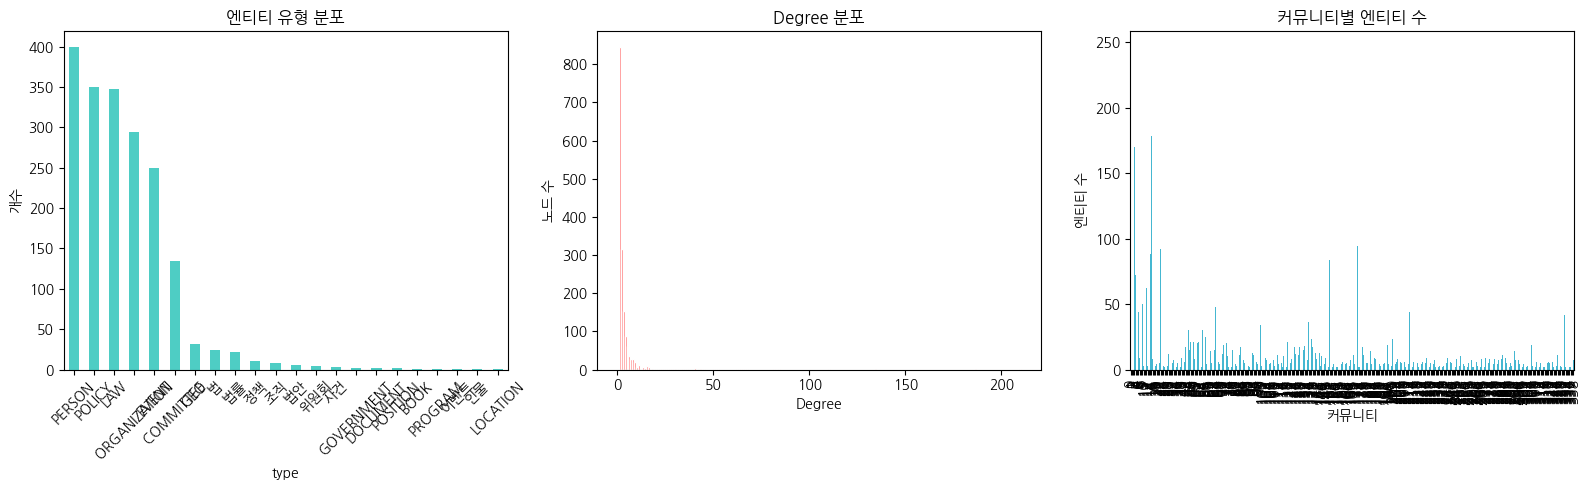

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

type_counts = entities['type'].value_counts()
type_counts.plot(kind='bar', ax=axes[0], color='#4ECDC4')
axes[0].set_title('엔티티 유형 분포')
axes[0].set_ylabel('개수')
axes[0].tick_params(axis='x', rotation=45)

degrees = [g.degree(n) for n in g.nodes()]
axes[1].hist(degrees, bins=range(0, max(degrees)+2), color='#FF6B6B', edgecolor='white')
axes[1].set_title('Degree 분포')
axes[1].set_xlabel('Degree')
axes[1].set_ylabel('노드 수')

if 'size' in communities.columns:
    comm_sizes = communities['size']
elif 'entity_ids' in communities.columns:
    comm_sizes = communities['entity_ids'].apply(lambda x: len(x) if isinstance(x, list) else 0)
else:
    comm_sizes = pd.Series([1] * len(communities))

comm_sizes.plot(kind='bar', ax=axes[2], color='#45B7D1')
axes[2].set_title('커뮤니티별 엔티티 수')
axes[2].set_xlabel('커뮤니티')
axes[2].set_ylabel('엔티티 수')

plt.tight_layout()
plt.show()

In [ ]:
# 엔티티 추출이 잘 됐는지
# 1. 청크 샘플링
# 2. 그 청크에서 graphrag 가 추출한 엔티티 조회
# 3. LLM 물어보기 : 맞는지? 빠진건 없는지? type은 제대로 ?
# 4. precision, recall

In [79]:
from openai import OpenAI
from dotenv import load_dotenv
load_dotenv()
client = OpenAI()

In [84]:
def evaluate_entity_extraction(chunk_text, extracted_entities, model = 'gpt-4o-mini'):
    entity_list = '\n'.join(
        f"- {row['title']} ({row['type']}) : {row.get('description', 'N/A')[:100]}"
        for _, row in extracted_entities.iterrows()
    )

    prompt = f"""당신은 한국어 텍스트에서 엔티티 추출 품질을 평가하는 전문가입니다.

    ### 텍스트 (원본 청크)
    {chunk_text[:2000]}

    ### 시스템이 추출한 엔티티
    {entity_list if entity_list.strip() else "(없음)"}

    ### 평가 기준
    다음 JSON 형식으로 응답하세요:
    {{
        'precision_score' : 0.0 ~ 1.0,
        'recall_score' : 0.0 ~ 1.0,
    'false_positives' : ['잘못 추출된 엔티티'],
    'false_negatives' : ['누락된 중요 엔티티'],
    'type_accuracy' : 0.0 ~ 1.0,
    'reasoning' : '간단한 판단 근거'
    }}"""

    response = client.chat.completions.create(
        model = model,
        messages = [{'role' : 'user', 'content' : prompt}],
        temperature= 0,
        response_format= {'type' : 'json_object'}
    )
    return json.loads(response.choices[0].message.content)

In [85]:
sample_indices = np.random.choice(len(text_units), size=min(5, len(text_units)), replace=False)
sample_indices

array([467, 320,  49,  42, 387])

In [86]:
text_units.head(1)

,id,human_readable_id,text,n_tokens,document_id,entity_ids,relationship_ids,covariate_ids
0,ee29fdac7631f04fe228b326909e3f9bcb9d81f0b919aa...,0,# 제22대 제433회 제3차 과학기술정보방송통신위원회 (2026년 04월 01일)...,600,c1a9e052a208b7767d15110ffac8d05cd5211701e469bb...,"[2e8e56ec-62f7-431a-b860-fc7751e4eef6, 45c53c0...","[cdcac2ad-544f-4c6a-a2e4-50de7ee5d04d, 9cfc3c6...",[]


In [89]:
sample_indices = np.random.choice(len(text_units), size=min(5, len(text_units)), replace=False)

results = []
for idx in sample_indices:
    chunk = text_units.iloc[idx]
    chunk_text = chunk['text']

    chunk_entity_ids = chunk.get('entity_ids', [])
    if isinstance(chunk_entity_ids, str):
        chunk_entity_ids = json.loads(chunk_entity_ids)

    if len(chunk_entity_ids) > 0:
        chunk_entities = entities[entities['id'].isin(chunk_entity_ids)]
    else:
        chunk_entities = pd.DataFrame()

    print(f"청크 {idx}: {len(chunk_text)}자, 추출된 엔티티 {len(chunk_entities)}개")

    result = evaluate_entity_extraction(chunk_text, chunk_entities)
    result['chunk_idx'] = idx
    result['n_entities'] = len(chunk_entities)
    results.append(result)

    print(f"  정밀도: {result['precision_score']:.2f}, 재현율: {result['recall_score']:.2f}")
    if result.get('false_negatives'):
        print(f"  누락: {result['false_negatives'][:3]}")
    print()

avg_precision = np.mean([r['precision_score'] for r in results])
avg_recall = np.mean([r['recall_score'] for r in results])
avg_type_acc = np.mean([r['type_accuracy'] for r in results])
f1 = 2 * avg_precision * avg_recall / (avg_precision + avg_recall) if (avg_precision + avg_recall) > 0 else 0

print("=== 엔티티 추출 품질 요약 ===")
print(f"  평균 정밀도: {avg_precision:.2f}")
print(f"  평균 재현율: {avg_recall:.2f}")
print(f"  F1 Score:    {f1:.2f}")
print(f"  유형 정확도: {avg_type_acc:.2f}")

청크 187: 951자, 추출된 엔티티 10개
  정밀도: 0.80, 재현율: 0.80
  누락: ['시민단체', '뉴스공장']

청크 382: 976자, 추출된 엔티티 9개
  정밀도: 0.75, 재현율: 0.75
  누락: ['AI 데이터센터', 'LNG', '신에너지']

청크 23: 975자, 추출된 엔티티 6개
  정밀도: 0.60, 재현율: 0.50
  누락: ['대통령 (TITLE)', 'SNS (PLATFORM)', 'SBS (ORGANIZATION)']

청크 290: 945자, 추출된 엔티티 9개
  정밀도: 0.75, 재현율: 0.75
  누락: ['양자 컴퓨팅']

청크 314: 1031자, 추출된 엔티티 16개
  정밀도: 0.75, 재현율: 0.75

=== 엔티티 추출 품질 요약 ===
  평균 정밀도: 0.73
  평균 재현율: 0.71
  F1 Score:    0.72
  유형 정확도: 0.82


## 평가용 질문 자동 생성

평가에 필요한 질문을 수동으로 만들면 시간이 많이 듭니다.
**커뮤니티 리포트를 기반으로 LLM 이 질문을 자동 생성** 하게 합니다.

In [90]:
def generate_eval_questions(reports_df, n_local=5, n_global=3, model="gpt-4o-mini"):
    """커뮤니티 리포트 기반 평가 질문 생성."""
    report_summaries = "\n\n".join(
        f"[커뮤니티: {row['title']}]\n{row['summary']}"
        for _, row in reports_df.iterrows()
    )

    prompt = f"""아래는 국회 과방위 회의록 분석 결과의 커뮤니티 요약입니다.

{report_summaries}

평가용 질문을 생성하세요.

### Local Search용 질문 ({n_local}개)
특정 인물·조직·법안에 대한 구체적 질문.

### Global Search용 질문 ({n_global}개)
전체 회의록을 종합해야 답할 수 있는 거시 질문.

다음 JSON 형식으로:
{{
  "local_questions":  ["..."],
  "global_questions": ["..."]
}}"""

    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.7,
        response_format={"type": "json_object"}
    )
    return json.loads(response.choices[0].message.content)


eval_questions = generate_eval_questions(reports)

print("=== Local Search용 질문 ===")
for i, q in enumerate(eval_questions['local_questions'], 1):
    print(f"  {i}. {q}")

print("\n=== Global Search용 질문 ===")
for i, q in enumerate(eval_questions['global_questions'], 1):
    print(f"  {i}. {q}")

=== Local Search용 질문 ===
  1. Go Gwang-heon은 방송통신심의위원회 위원장 후보로서 어떤 주요 이슈를 다루고 있나요?
  2. 이재명 정부의 가짜뉴스 근절을 위한 정책은 어떤 내용으로 구성되어 있나요?
  3. 박정권 의원이 제안한 정보통신망법 개정안의 주요 내용은 무엇인가요?
  4. 한민수 의원이 제안한 클라우드컴퓨팅 개발 및 사용자 보호법의 주요 내용은 무엇인가요?
  5. 강도성 위원은 방송미디어촉진국과의 협력에서 어떤 역할을 하고 있나요?

=== Global Search용 질문 ===
  1. South Korea의 방송 및 통신 규제 체계는 최근의 기술 발전에 어떻게 대응하고 있나요?
  2. K-스마트 시티 프로젝트와 관련된 법안들이 South Korea의 경제 및 기술 발전에 미치는 영향은 무엇인가요?
  3. South Korea의 데이터 보호 및 개인 정보 보호 법안들은 다양한 산업에 어떤 영향을 미치고 있나요?


---
## 답변 품질 평가 (LLM-as-a-Judge)

질문 → GraphRAG 질의 → 답변 → 4개 차원으로 점수화:

| 차원 | 설명 | 점수 |
|------|------|------|
| 충실성 (Faithfulness) | 답변이 원본 데이터에 근거하는가 | 1~5 |
| 관련성 (Relevance) | 질문에 직접 답하는가 | 1~5 |
| 완전성 (Completeness) | 중요 측면을 빠짐없이 다루는가 | 1~5 |
| 일관성 (Coherence) | 구조적이고 읽기 쉬운가 | 1~5 |

> Microsoft [BenchmarkQED](https://github.com/microsoft/benchmark-qed) 

In [91]:
def evaluate_answer(question, answer, model="gpt-4o-mini"):
    """LLM-as-a-Judge로 답변 품질을 평가합니다."""
    prompt = f"""당신은 RAG 시스템의 답변 품질을 평가하는 전문가입니다.

### 질문
{question}

### 시스템 답변
{answer}

### 평가 기준 (각 1~5)
1. faithfulness — 답변의 주장이 사실에 근거하는가
2. relevance — 질문에 직접 답하는가
3. completeness — 질문의 모든 측면을 다루는가
4. coherence — 논리적으로 구조화되어 있는가

다음 JSON 형식으로:
{{
  "faithfulness": 1~5,
  "relevance": 1~5,
  "completeness": 1~5,
  "coherence": 1~5,
  "reasoning": "..."
}}"""

    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        response_format={"type": "json_object"}
    )
    return json.loads(response.choices[0].message.content)

print("✓ evaluate_answer 정의 완료")

✓ evaluate_answer 정의 완료


In [93]:
import os, json, re, subprocess
def run_graphrag_query(question, method="local"):
    """GraphRAG CLI로 질의를 실행합니다."""
    cmd = [
        "graphrag", "query",
        "--root", str(PROJECT_ROOT),
        "--method", method,
        question  # positional argument
    ]
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=120)
    output = result.stdout
    if "SUCCESS:" in output:
        return output.split("SUCCESS:", 1)[1].strip()
    return output.strip()


print("=== Local Search 평가 ===\n")

local_scores = []
for i, q in enumerate(eval_questions['local_questions'][:3]):
    print(f"[질문 {i+1}] {q}")
    answer = run_graphrag_query(q, method="local")
    print(f"[답변] {answer[:200]}...")

    score = evaluate_answer(q, answer)
    local_scores.append(score)
    print(f"[평가] 충실성={score['faithfulness']} 관련성={score['relevance']} "
          f"완전성={score['completeness']} 일관성={score['coherence']}")
    print(f"[근거] {score['reasoning'][:100]}\n")

=== Local Search 평가 ===

[질문 1] Go Gwang-heon은 방송통신심의위원회 위원장 후보로서 어떤 주요 이슈를 다루고 있나요?
[답변] ## Go Gwang-heon의 주요 이슈 및 논의

Go Gwang-heon은 방송통신심의위원회 위원장 후보로 여러 중요한 이슈를 논의하며 미디어 규제의 혁신을 주장하고 있습니다. 그의 주요 초점은 다음과 같습니다.

### 1. 미디어 공정성과 독립성

고광헌은 방송의 공정성과 독립성 보장을 민주사회에서 필수적인 가치로 강조하고 있습니다. 그는 미디어 ...
[평가] 충실성=4 관련성=5 완전성=4 일관성=5
[근거] 답변은 Go Gwang-heon 후보가 다루고 있는 주요 이슈들을 잘 설명하고 있으며, 미디어 공정성, 기술 발전에 따른 규제 필요성, 예산 문제, 그리고 반론 및 비판을 포함하여

[질문 2] 이재명 정부의 가짜뉴스 근절을 위한 정책은 어떤 내용으로 구성되어 있나요?
[답변] ## 이재명 정부의 가짜뉴스 근절 정책

이재명 정부는 가짜뉴스, 즉 허위 정보를 근절하기 위한 여러 가지 정책과 법안을 추진하고 있습니다. 이러한 노력을 통해 미디어의 신뢰성을 높이고, 공공의 이해를 증진시키려는 방향성을 가지고 있으며, 다양한 이해관계자와의 협력을 통해 정책을 마련하고 있습니다.

### 정책의 주요 내용

1. **미디어 규제와 감독 ...
[평가] 충실성=4 관련성=5 완전성=4 일관성=5
[근거] 답변은 이재명 정부의 가짜뉴스 근절 정책에 대한 주요 내용을 잘 설명하고 있으며, 관련 법률과 정책의 방향성을 명확히 제시하고 있습니다. 그러나 구체적인 사례나 최근의 정책 변화에

[질문 3] 박정권 의원이 제안한 정보통신망법 개정안의 주요 내용은 무엇인가요?
[답변] ## 박정권 의원의 정보통신망법 개정안 주요 내용

박정권 의원이 제안한 정보통신망법 개정안은 정보통신망의 이용 촉진과 정보 보호를 중심으로 하는 두 가지 핵심 목표에 초점을 맞추고 있습니다. 이 법안은 디지털 환경에서의 정보

---
## 개선 전략

| 문제 | 원인 | 해결책 |
|------|------|--------|
| 재현율 낮음 | 청크 큼/글리닝 부족 | `chunking.size` ↓, `max_gleanings` ↑ |
| 정밀도 낮음 | 도메인 안 맞는 유형 | `entity_types` 조정 |
| 고립 노드 많음 | 관계 추출 부족 | 프롬프트에 관계 강조 |
| Local 답변 불완전 | 청크 부족 | `local_search.text_unit_prop` ↑ |
| Global 답변 피상적 | 리포트 짧음 | `community_reports.max_length` ↑ |

### 반복적 개선 루프

```
인덱싱 → 평가 → 진단 → 설정 조정 → 재인덱싱 → 재평가 → ...
```